In [8]:
!pip install ultralytics -q
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
 print("Device:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.9 MB/s eta 0:00:00
GPU available: True
Device: Tesla T4


In [10]:
!mkdir -p /root/.kaggle


In [11]:
%%writefile /root/.kaggle/kaggle.json
{
  "username": "Pragnya",
  "key": "KGAT_4ea62a56f31eb4168b018fa71f085041"
}

Writing /root/.kaggle/kaggle.json


In [12]:
!chmod 600 /root/.kaggle/kaggle.json

In [13]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:23<00:00, 41.5MB/s]



In [14]:
!unzip icg-spacenet-sandox-yolo.zip -d dataset

Archive:  icg-spacenet-sandox-yolo.zip
  inflating: dataset/spacenet_buildings_yolo/README.md  
  inflating: dataset/spacenet_buildings_yolo/dataset.yaml.template  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img10.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img100.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1000.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1001.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1003.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1007.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1008.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1009.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img101.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_Paris_img1010.png  
  inflating: dataset/spacenet_buildings_yolo/images/AOI_3_P

In [15]:
!ls

dataset  icg-spacenet-sandox-yolo.zip  sample_data


In [16]:
!find /content -maxdepth 3 -type d | grep -iE 'image|label|train|val|test'
import glob
print("Images:", len(glob.glob('/content/**/*.png', recursive=True)))
print("Labels:", len(glob.glob('/content/**/*.txt', recursive=True)))


/content/dataset/spacenet_buildings_yolo/images
/content/dataset/spacenet_buildings_yolo/labels
Images: 1148
Labels: 1148


In [17]:
!find . -type d | head -30

.
./.config
./.config/logs
./.config/logs/2026.06.04
./.config/configurations
./dataset
./dataset/spacenet_buildings_yolo
./dataset/spacenet_buildings_yolo/images
./dataset/spacenet_buildings_yolo/labels
./sample_data


In [18]:
import os
import shutil
from sklearn.model_selection import train_test_split

image_dir = "/content/dataset/spacenet_buildings_yolo/images"
label_dir = "/content/dataset/spacenet_buildings_yolo/labels"

images = [
    f for f in os.listdir(image_dir)
    if f.endswith((".png"))
]

# 80% train, 20% temp
train_imgs, temp_imgs = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

# remaining 20% -> 10% val + 10% test
val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.5,
    random_state=42
)

In [19]:
import os

splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{image_dir}/{split}", exist_ok=True)
    os.makedirs(f"{label_dir}/{split}", exist_ok=True)

print("Folders created!")

Folders created!


In [20]:
import shutil

def move_files(file_list, split):

    for img_name in file_list:

        # image source
        img_src = os.path.join(image_dir, img_name)

        # image destination
        img_dst = os.path.join(
            image_dir,
            split,
            img_name
        )

        shutil.move(img_src, img_dst)

        # matching label
        label_name = img_name.replace(".png", ".txt")

        label_src = os.path.join(
            label_dir,
            label_name
        )

        if os.path.exists(label_src):

            label_dst = os.path.join(
                label_dir,
                split,
                label_name
            )

            shutil.move(label_src, label_dst)

In [21]:
move_files(train_imgs, "train")
move_files(val_imgs, "val")
move_files(test_imgs, "test")

print("Dataset split completed!")

Dataset split completed!


In [22]:
print("Train:", len(os.listdir(f"{image_dir}/train")))
print("Val:", len(os.listdir(f"{image_dir}/val")))
print("Test:", len(os.listdir(f"{image_dir}/test")))

Train: 918
Val: 115
Test: 115


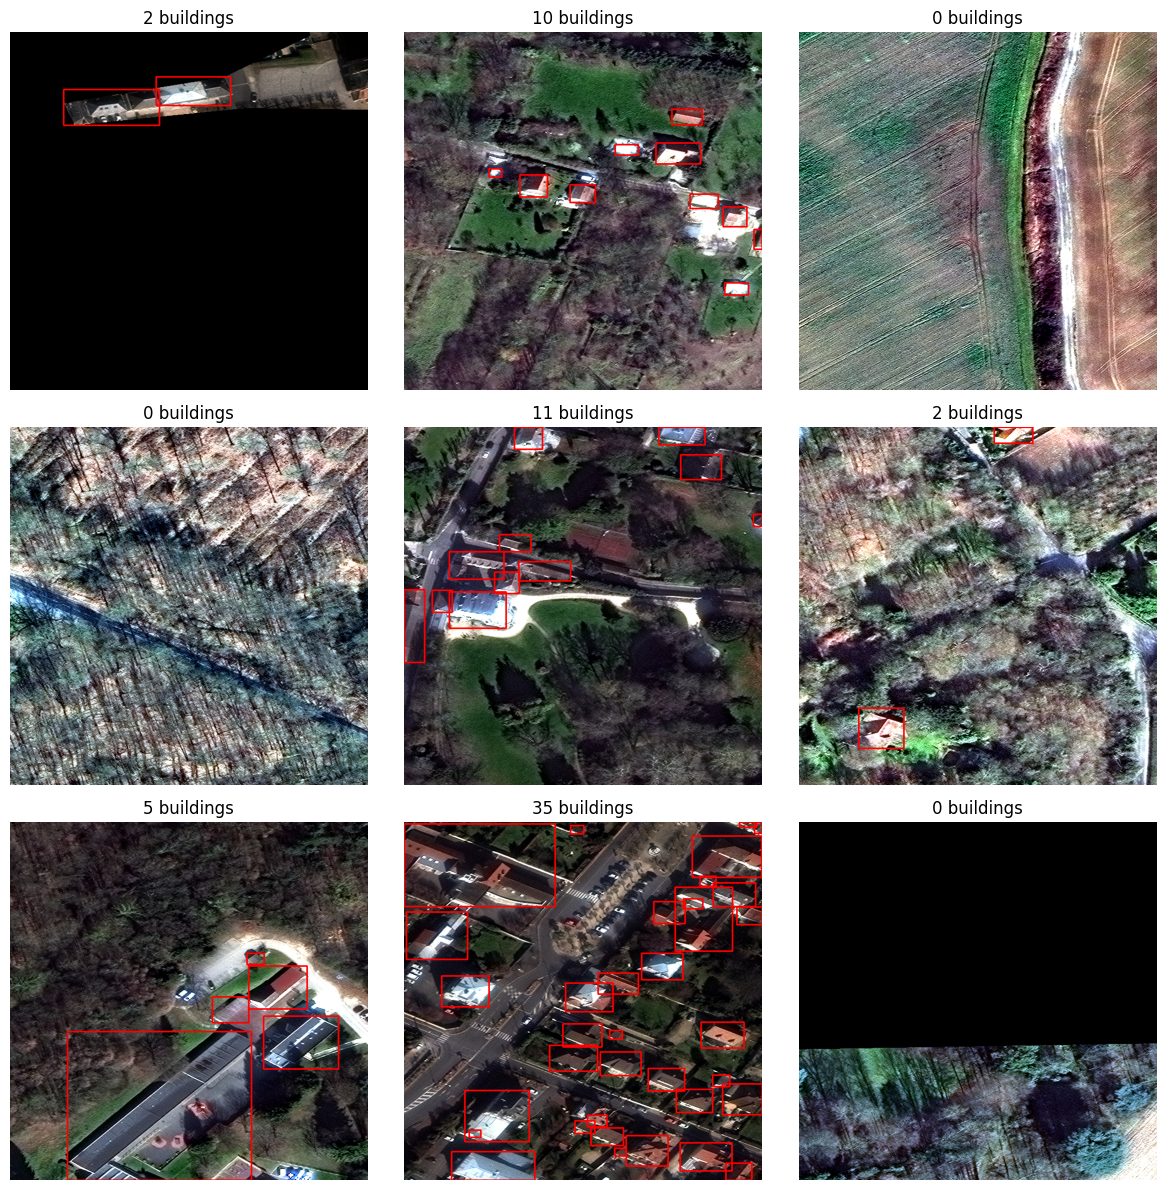

In [23]:
import random
import cv2
import matplotlib.pyplot as plt
import os

train_img_dir = f"{image_dir}/train"
train_label_dir = f"{label_dir}/train"

random_images = random.sample(
    os.listdir(train_img_dir),
    9
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)
for ax, img_name in zip(axes.ravel(), random_images):

    img_path = os.path.join(
        train_img_dir,
        img_name
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    h, w, _ = img.shape

    label_path = os.path.join(
        train_label_dir,
        os.path.splitext(img_name)[0] + ".txt"
    )

    building_count = 0

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            for line in f:

                cls, x, y, bw, bh = map(
                    float,
                    line.strip().split()
                )

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)

                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                building_count += 1

    ax.imshow(img)
    ax.set_title(
        f"{building_count} buildings"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import os

label_files = os.listdir(train_label_dir)

total_buildings = 0

for file in label_files:

    with open(
        os.path.join(train_label_dir, file),
        "r"
    ) as f:

        total_buildings += len(
            f.readlines()
        )

avg_buildings = (
    total_buildings /
    len(label_files)
)

print(
    "Average buildings per image:",
    round(avg_buildings, 2)
)

Average buildings per image: 14.3


Average number of buildings per image: 14.3

Yes, Most images have same resolution and are from same satellite source.

Problems may occur when buildings are partially visible at boundaries or when shadows obscure buildings.

In [24]:
%%writefile dataset.yaml

path: /content/dataset/spacenet_buildings_yolo

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building

Writing dataset.yaml


In [25]:
!cat dataset.yaml


path: /content/dataset/spacenet_buildings_yolo

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building


We use yolov8s.pt because it contains pretrained weights learned from a large dataset. Starting from pretrained weights allows the model to learn faster and achieve better performance compared to training from random initialization.

In [26]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [27]:
results = model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    project="runs",
    name="building_detector"
)

Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=building_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

In [28]:
import pandas as pd

df = pd.read_csv(
    "/content/runs/detect/runs/building_detector/results.csv"
)

df.tail(1)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
19,20,510.561,1.25079,0.75008,1.1439,0.83469,0.74769,0.82721,0.50396,1.31146,0.78568,1.18364,0.000119,0.000119,0.000119


In [29]:
final_box_loss = df["train/box_loss"].iloc[-1]
final_map50 = df["metrics/mAP50(B)"].iloc[-1]

print("Final Box Loss:", final_box_loss)
print("Final mAP50:", final_map50)

Final Box Loss: 1.25079
Final mAP50: 0.82721


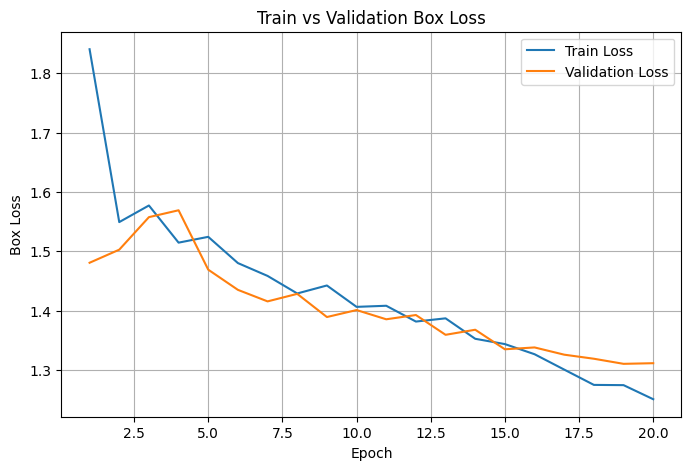

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df["epoch"], df["train/box_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Train vs Validation Box Loss")
plt.legend()
plt.grid()

plt.show()

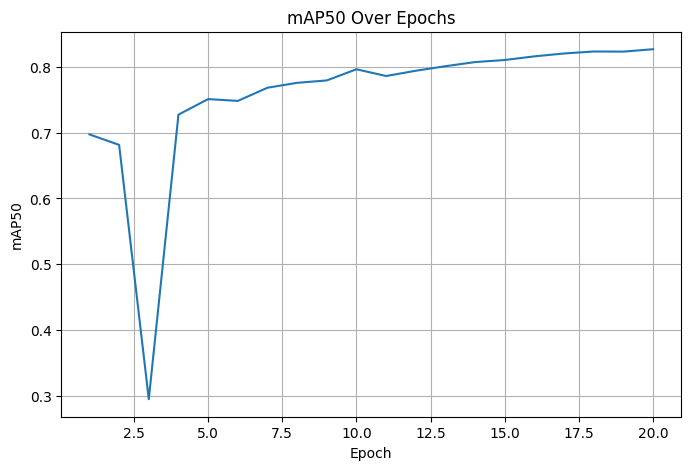

In [31]:
plt.figure(figsize=(8,5))

plt.plot(df["epoch"], df["metrics/mAP50(B)"])

plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("mAP50 Over Epochs")
plt.grid()

plt.show()

The validation loss generally followed the training loss throughout training, indicating that the model learned consistently and did not show severe overfitting. The mAP50 improved rapidly during the initial epochs and gradually plateaued near the end, suggesting that the model was approaching convergence.

In [32]:
metrics = model.val()

Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3573.0±1303.1 MB/s, size: 713.3 KB)
val: Scanning /content/dataset/spacenet_buildings_yolo/labels/val.cache... 115 images, 52 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 48.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.4s
                   all        115       2057      0.831       0.75      0.828      0.504
Speed: 5.7ms preprocess, 10.5ms inference, 0.0ms loss, 7.3ms postprocess per image
Results saved to /content/runs/detect/val


In [33]:
print(metrics.box.mp)      # Precision
print(metrics.box.mr)      # Recall
print(metrics.box.map50)   # mAP50

0.8313055625398127
0.7498424225190234
0.8276132059325052


In [34]:
P = metrics.box.mp
R = metrics.box.mr

F1 = 2 * P * R / (P + R)

print("F1 Score:", F1)

F1 Score: 0.7884754403240722


| Metric | Your Value | What it means in plain English |
|----------|----------|----------|
| mAP@50 | 0.8276 | Overall detection accuracy at IoU=0.5 |
| Precision | 0.8313 | 83.1% of predicted buildings were correct |
| Recall | 0.7498 | 74.9% of actual buildings were detected |
| F1 Score | 0.788 | Harmonic mean of precision and recall |

In [35]:
!find /content -name "best.pt"

/content/runs/detect/runs/building_detector/weights/best.pt


In [36]:
!find /content -name "*.png" | grep -E "PR|confusion|results"

/content/runs/detect/runs/building_detector/confusion_matrix.png
/content/runs/detect/runs/building_detector/confusion_matrix_normalized.png
/content/runs/detect/runs/building_detector/results.png
/content/runs/detect/runs/building_detector/BoxPR_curve.png
/content/runs/detect/val/confusion_matrix.png
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/BoxPR_curve.png


In [37]:
P = metrics.box.mp
R = metrics.box.mr

F1 = 2 * P * R / (P + R)

print("Precision =", P)
print("Recall =", R)
print("mAP50 =", metrics.box.map50)
print("F1 =", F1)

Precision = 0.8313055625398127
Recall = 0.7498424225190234
mAP50 = 0.8276132059325052
F1 = 0.7884754403240722


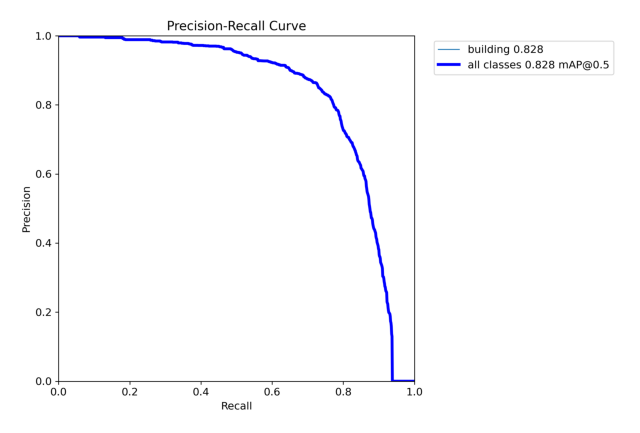

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
    "/content/runs/detect/val/BoxPR_curve.png"
)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

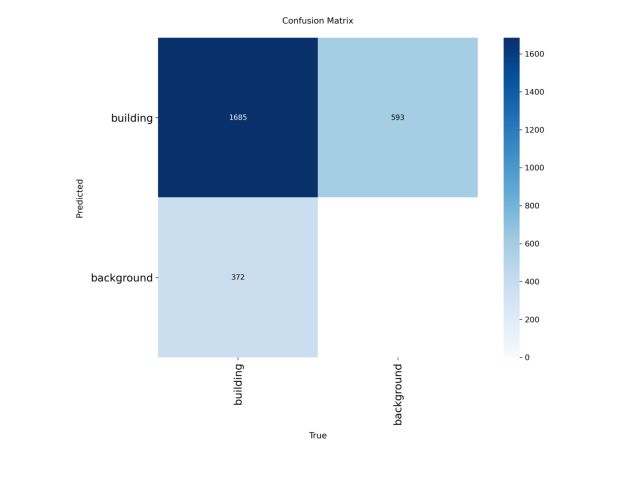

In [39]:
img = Image.open(
    "/content/runs/detect/val/confusion_matrix.png"
)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [40]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/detect/runs/building_detector/weights/best.pt"
)
def detect_buildings(image_path):

    results = best_model(image_path)

    count = len(results[0].boxes)

    return count

In [41]:
import random
import os

test_img_dir = "/content/dataset/spacenet_buildings_yolo/images/test"

test_images = random.sample(
    os.listdir(test_img_dir),
    10
)

test_images
true_counts = []
pred_counts = []

for img_name in test_images:

    image_path = os.path.join(
        test_img_dir,
        img_name
    )

    label_path = os.path.join(
        "/content/dataset/spacenet_buildings_yolo/labels/test",
        os.path.splitext(img_name)[0] + ".txt"
    )

    # true count
    if os.path.exists(label_path):
        with open(label_path) as f:
            true_count = len(f.readlines())
    else:
        true_count = 0

    # predicted count
    pred_count = detect_buildings(image_path)

    true_counts.append(true_count)
    pred_counts.append(pred_count)


image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img796.png: 640x640 (no detections), 16.1ms
Speed: 3.0ms preprocess, 16.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img954.png: 640x640 49 buildings, 16.1ms
Speed: 2.6ms preprocess, 16.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img101.png: 640x640 34 buildings, 15.7ms
Speed: 2.5ms preprocess, 15.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img245.png: 640x640 1 building, 15.8ms
Speed: 2.3ms preprocess, 15.8ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img260.png: 640x640 6 buildings, 15.7ms
Speed: 2.3ms preprocess, 15

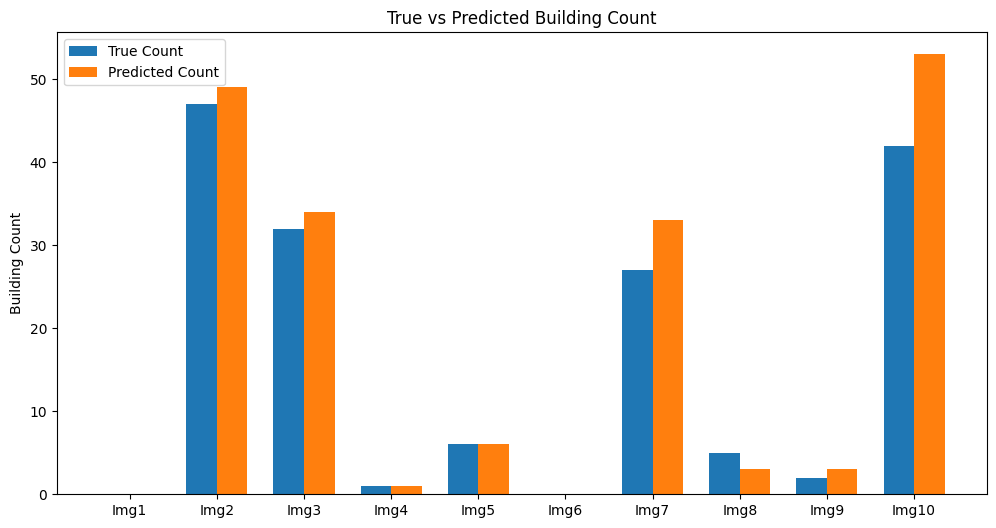

In [42]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(test_images))

width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    true_counts,
    width,
    label="True Count"
)

plt.bar(
    x + width/2,
    pred_counts,
    width,
    label="Predicted Count"
)

plt.xticks(
    x,
    [f"Img{i+1}" for i in range(10)]
)

plt.ylabel("Building Count")
plt.title(
    "True vs Predicted Building Count"
)

plt.legend()
plt.show()

In [43]:
import time
import cv2
import matplotlib.pyplot as plt

def building_pipeline(image_path):

    start = time.time()

    results = best_model(image_path)

    elapsed = (
        time.time() - start
    ) * 1000

    boxes = results[0].boxes

    count = len(boxes)

    if count > 0:
        avg_conf = (
            boxes.conf.mean().item()
        )
    else:
        avg_conf = 0

    annotated = results[0].plot()

    original = cv2.imread(image_path)
    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(annotated)
    plt.title("Detected Buildings")
    plt.axis("off")

    plt.show()

    print(
        f"Image: {os.path.basename(image_path)}"
    )

    print(
        f"Buildings detected: {count}"
    )

    print(
        f"Avg confidence: {avg_conf:.2f}"
    )

    print(
        f"Processing time: {elapsed:.2f} ms"
    )


image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img1906.png: 640x640 18 buildings, 46.5ms
Speed: 15.0ms preprocess, 46.5ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 640)


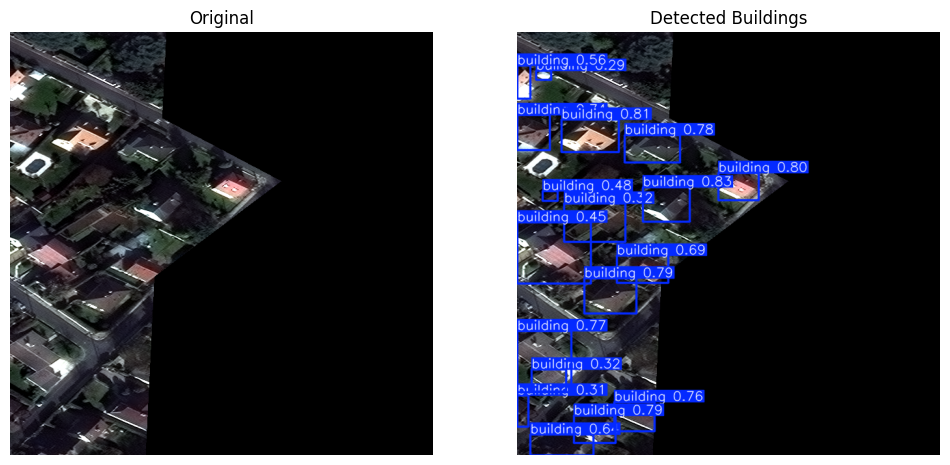

Image: AOI_3_Paris_img1906.png
Buildings detected: 18
Avg confidence: 0.62
Processing time: 123.41 ms

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img292.png: 640x640 1 building, 20.8ms
Speed: 8.2ms preprocess, 20.8ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


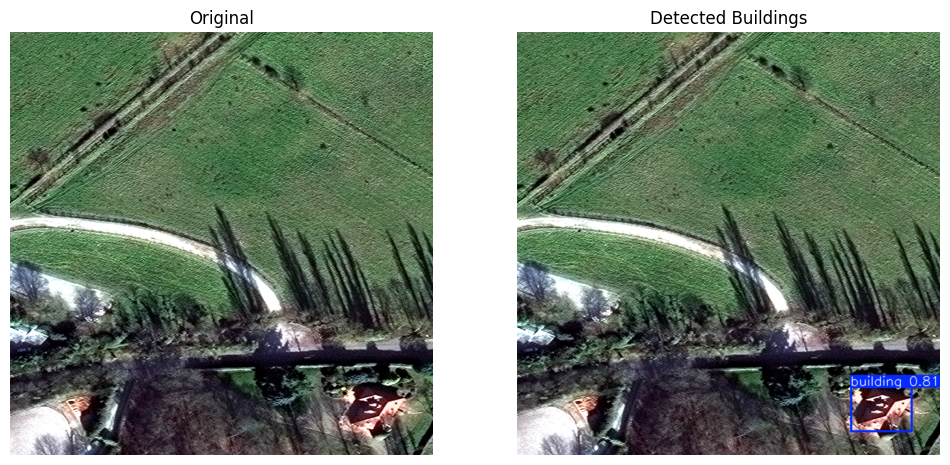

Image: AOI_3_Paris_img292.png
Buildings detected: 1
Avg confidence: 0.81
Processing time: 89.16 ms

image 1/1 /content/dataset/spacenet_buildings_yolo/images/test/AOI_3_Paris_img1108.png: 640x640 (no detections), 15.9ms
Speed: 4.3ms preprocess, 15.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


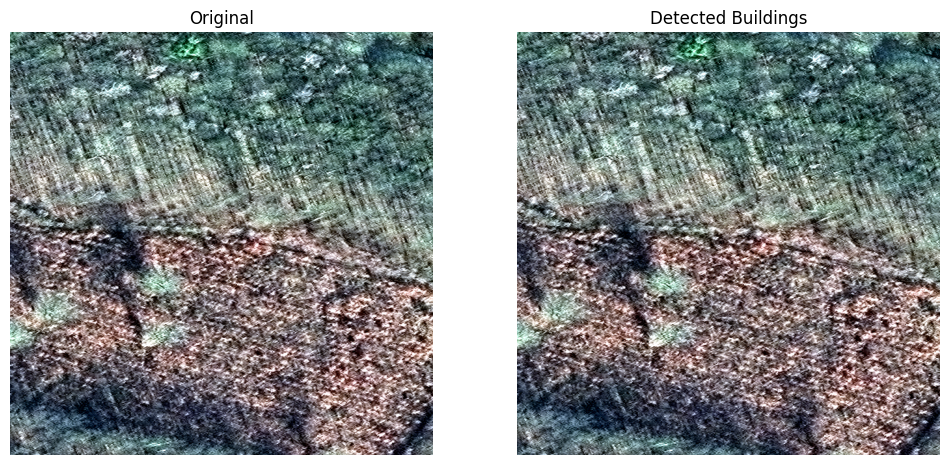

Image: AOI_3_Paris_img1108.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 41.47 ms


In [44]:
sample_images = random.sample(
    os.listdir(test_img_dir),
    3
)

for img in sample_images:

    building_pipeline(
        os.path.join(
            test_img_dir,
            img
        )
    )